# Deep Learning / Neural Networks (CS229) — Practical Implementation

## 1. Introduction

This notebook is the **practical companion** to the CS229 notes on Deep Learning:
non-linear models, the single neuron, stacking neurons into fully-connected
networks, vectorization, activation functions, and training with (mini-batch)
SGD + backpropagation.

**Concept implemented:** A **feedforward fully-connected neural network**
(multi-layer perceptron, MLP) for **binary classification**, trained with
(mini-batch) stochastic gradient descent, where the gradients are computed
internally via **backpropagation**.

**Problem we are solving:** Predict whether a bank customer will **churn**
(close their account) based on their profile and account activity.

**Dataset:** `churn.csv` — 10,000 bank customers with demographic and account
features (credit score, geography, gender, age, tenure, balance, number of
products, credit card ownership, activity status, estimated salary).

**Target variable:** `Exited` — binary (`1` = customer churned, `0` = customer
stayed).

**Machine Learning task:** **Binary classification.**

This is a natural fit for the CS229 deep learning notes: `Exited` is a binary
outcome, exactly the case discussed in Section 7.1 ("Binary classification"),
where the network outputs a **logit** $\bar h_\theta(x)$, the **sigmoid**
turns it into a probability, and the **logistic loss** is minimized via
gradient-based optimization computed through **backpropagation**.


## 2. Import Libraries

We use `sklearn.neural_network.MLPClassifier` — sklearn's fully-connected feedforward neural network implementation — instead of writing forward/backward passes by hand, exactly as the notes describe ("in practice ... a researcher does not need to write their backpropagation algorithms").

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    log_loss,
)

# Reproducibility: fix the random seed used anywhere randomness is involved
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")


## 3. Load the Dataset

In [7]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_07_NN & Non-Linear Models\Dataset.csv")

# A quick look at the first rows tells us what the raw features look like
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# Shape: rows = number of customers (examples), columns = features + target
df.shape


(10000, 14)

In [9]:
# Data types tell us which columns are numeric and which are categorical (strings)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [10]:
# Summary statistics for numeric columns
df.describe()


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
# Check for missing values encoded as NaN
df.isnull().sum()


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## 4. Understand the Data

**Raw columns:** `RowNumber`, `CustomerId`, `Surname`, `CreditScore`,
`Geography`, `Gender`, `Age`, `Tenure`, `Balance`, `NumOfProducts`,
`HasCrCard`, `IsActiveMember`, `EstimatedSalary`, `Exited`.

- `RowNumber`, `CustomerId`, `Surname` are **identifiers**, not predictive
  features — a customer's row number or database ID carries no information
  about whether they will churn, and including them would let the network
  "memorize" individual customers rather than learn a generalizable pattern.
  We drop these three columns.
- **Numerical features:** `CreditScore`, `Age`, `Tenure`, `Balance`,
  `NumOfProducts`, `EstimatedSalary` (`HasCrCard` and `IsActiveMember` are
  already binary 0/1, so we treat them as numeric too).
- **Categorical features:** `Geography` (France/Spain/Germany), `Gender`
  (Female/Male) — text labels that must be converted to numbers.
- **Target:** `Exited` (0 = stayed, 1 = churned).

`df.isnull().sum()` shows **no missing values**, and `df.describe()` shows no
obviously invalid values (e.g. no negative ages or balances) — this dataset
does not have the "impossible zero" issue we might see elsewhere.


In [12]:
# Check the target class balance — important for a neural network trained
# with logistic loss, since a skewed target can bias the learned decision boundary
df["Exited"].value_counts(normalize=True).rename("proportion")


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

> ⚠️ **Data issue found:** the target is **imbalanced** — about 80% of customers stayed and only 20% churned. A network trained naively will tend to lean toward predicting "stayed" for everyone (which alone gives ~80% accuracy without learning anything useful). We account for this by looking at precision/recall/F1/ROC-AUC in addition to accuracy, rather than relying on accuracy alone.

C:\Users\img\AppData\Local\Temp\ipykernel_31432\2158563259.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Exited", data=df, palette=["#4C72B0", "#DD8452"])


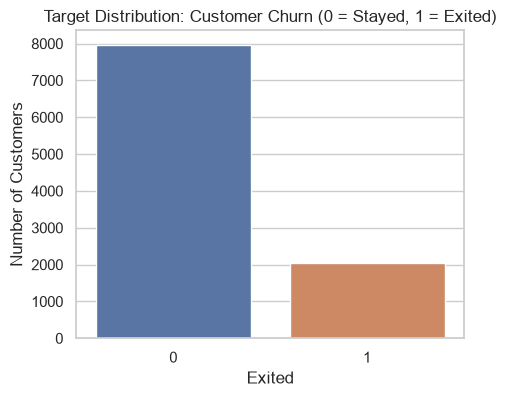

In [13]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Exited", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Target Distribution: Customer Churn (0 = Stayed, 1 = Exited)")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()


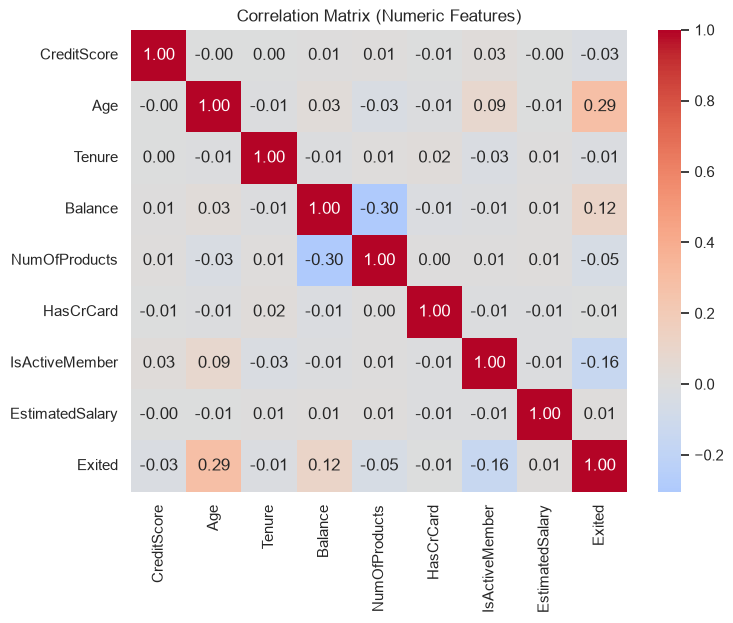

In [14]:
# Correlation matrix for numeric features and the target
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                 "HasCrCard", "IsActiveMember", "EstimatedSalary", "Exited"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


`Age` and `IsActiveMember` show the strongest (linear) association with churn. As with any non-linear model, a neural network can also pick up interactions and non-linear patterns that a simple correlation matrix cannot show — which is part of why we use one here instead of, say, plain logistic regression.

## 5. Data Preprocessing

Recall from the CS229 notes (Section 7.2, "Vectorization"): the first layer of
the network computes
$$
z = W^{[1]}x + b^{[1]}
$$
This is a weighted **linear combination** of the raw input features. If one
feature (e.g. `Balance`, which ranges into the hundreds of thousands) has a
much larger numeric scale than another (e.g. `Tenure`, which ranges 0–10),
the network's initial gradients and learned weights will be dominated by the
large-scale feature — training becomes slower and less stable. So we:

1. Drop non-predictive identifier columns (`RowNumber`, `CustomerId`,
   `Surname`).
2. **One-hot encode** categorical features (`Geography`, `Gender`) — a
   neural network's `MM` (matrix multiplication) module needs numeric input,
   it cannot directly multiply a weight vector by the string `"France"`.
3. **Standardize** numeric features to zero mean / unit variance, so every
   input dimension contributes on a comparable scale to the very first
   weighted sum $W^{[1]}x + b^{[1]}$.

> ⚠️ **Important:** All preprocessing statistics (mean/std for scaling, the
> set of one-hot categories) must be learned **only from the training set**,
> then applied unchanged to the test set — otherwise information from the
> test set would leak into training, giving an overly optimistic evaluation.


In [15]:
# Step 1: Drop identifier columns that carry no predictive signal
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

df_clean.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
# Step 2: Separate features (X) from the target (y)
# X -> the input feature vectors x^(i) fed into the network
# y -> the labels y^(i) in {0, 1}, matching the CS229 binary classification setup
X = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"]

numeric_features = ["CreditScore", "Age", "Tenure", "Balance",
                     "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]
categorical_features = ["Geography", "Gender"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical features: ['Geography', 'Gender']


## 6. Train/Test Split

- `X` represents the input feature vectors ($x^{(i)}$ in the CS229 notes).
- `y` represents the class labels ($y^{(i)} \in \{0,1\}$).

We split **before** fitting any preprocessing (scaler/encoder), so the
test set's statistics never influence training. The **training set** is
used to learn the network's parameters $\theta = \{W^{[1]}, b^{[1]}, \dots,
W^{[r]}, b^{[r]}\}$ via backpropagation + SGD. The **test set** is held out
and used only at the end, to estimate how the network generalizes to new,
unseen customers — a network that only fits the training data well but fails
on new customers would be useless for actually predicting future churn.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # keep the same churn proportion in train and test, given the class imbalance
)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Test set size: {X_test.shape[0]} customers")


Training set size: 8000 customers
Test set size: 2000 customers


In [18]:
# Build a preprocessing pipeline:
#  - numeric columns: standardize (zero mean, unit variance)
#  - categorical columns: one-hot encode
# Wrapping this in a ColumnTransformer + Pipeline ensures all statistics
# are learned ONLY on X_train via .fit(), and simply applied (not re-learned)
# on X_test via .transform().
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


## 7. Connect Theory to Code

```text
CS229 Theory
     |
Single neuron: ReLU(w^T x + b)
     |
Stacked neurons -> fully-connected multi-layer network (Section 7.2)
     |
Vectorized forward pass: a[k] = ReLU(W[k] a[k-1] + b[k])   (Section 7.2)
     |
Output layer (binary classification): sigmoid(z[r]) -> probability   (Section 7.1)
     |
Loss: logistic loss (negative log-likelihood)   (Section 7.1)
     |
Training objective: J(theta) = (1/n) * sum_i J(i)(theta)   (Eq. 7.2/7.4)
     |
Optimization: (mini-batch) SGD, gradients via Backpropagation (Sections 7.1, 7.4)
     |
sklearn: MLPClassifier(hidden_layer_sizes=..., activation=..., solver=...)
     |
.fit(X_train, y_train)  -> runs forward pass + backprop + SGD updates, learns W[k], b[k]
     |
.predict(X_test) / .predict_proba(X_test)
```

**Mapping table:**

| CS229 symbol / concept | Meaning | sklearn equivalent |
|---|---|---|
| $x^{(i)}$ | input feature vector | a row of `X_train` (after preprocessing) |
| $y^{(i)} \in \{0,1\}$ | churn label | `y_train` |
| $W^{[k]}, b^{[k]}$ | weight matrix / bias for layer $k$ | `model.coefs_[k]`, `model.intercepts_[k]` |
| hidden layer sizes $m_1,\dots,m_{r-1}$ | number of hidden units per layer | `hidden_layer_sizes=(...)` |
| ReLU activation $\sigma$ | non-linear activation | `activation='relu'` |
| $\bar h_\theta(x)$ (logit) $\to$ sigmoid | binary classification output | last layer + internal sigmoid (`predict_proba`) |
| $J(\theta) = \frac1n\sum_i J^{(i)}(\theta)$ | average logistic loss | `model.loss_` (final training loss) |
| (mini-batch) SGD (Algorithms 1 & 2) | parameter update rule | `solver='sgd'` or `'adam'`, `batch_size=...`, `learning_rate_init=...` |
| Backpropagation (Section 7.4) | efficient gradient computation | computed internally by `MLPClassifier.fit()` |

We now implement this directly with `sklearn.neural_network.MLPClassifier`,
which internally builds a fully-connected feedforward network, runs the
forward pass, computes gradients via backpropagation, and updates parameters
via (mini-batch) SGD — exactly the pipeline derived in the CS229 notes.


## 8. Model Implementation

**Mathematical formulation (binary classification, Section 7.1 & 7.2):**

$$
a^{[1]} = \text{ReLU}(W^{[1]}x+b^{[1]}), \quad \dots, \quad \bar h_\theta(x) = W^{[r]}a^{[r-1]}+b^{[r]}
$$
$$
h_\theta(x) = \frac{1}{1+\exp(-\bar h_\theta(x))}, \qquad J^{(i)}(\theta) = -\log p(y^{(i)}\mid x^{(i)};\theta)
$$

- $\bar h_\theta(x)$ → the network's raw output (**logit**) before the sigmoid.
- $h_\theta(x)$ → the predicted **probability** that the customer churns.
- $J^{(i)}(\theta)$ → the logistic loss for a single customer; the network is
  trained to minimize its **average** over all training customers.

**Key hyperparameters** (all map directly to CS229 concepts):
- `hidden_layer_sizes=(16, 8)` → two hidden layers with 16 and 8 units,
  i.e. $m_1=16$, $m_2=8$ — this makes it a **3-layer** fully-connected
  network (2 hidden layers + 1 output layer), following Section 7.2's
  multi-layer definition.
- `activation='relu'` → the $\sigma(\cdot)$ used in every hidden layer
  (Section 7.2, Equation 7.23).
- `solver='adam'` → an SGD variant (adaptive per-parameter learning rates);
  we compare it explicitly to plain `'sgd'` in Section 14.
- `max_iter=300` → maximum number of passes over the training data
  (epochs).

`.fit()` is where the theory becomes concrete: sklearn runs the **forward
pass** (Section 7.2/7.3) to compute the loss, the **backward pass**
(Section 7.4, backpropagation) to compute $\nabla_\theta J(\theta)$, and then
an **SGD-style update** (Section 7.1, Algorithms 1/2) to adjust
$W^{[1]},b^{[1]},\dots,W^{[r]},b^{[r]}$ — repeated for `max_iter` epochs or
until convergence.


In [19]:
mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(16, 8),   # two hidden layers: m1=16, m2=8 hidden units
        activation="relu",            # ReLU activation, as introduced in Section 7.2
        solver="adam",                # an SGD variant (Section 7.1)
        learning_rate_init=0.001,
        max_iter=300,
        random_state=RANDOM_STATE,
    )),
])

# .fit() runs: forward pass -> compute loss -> backpropagation -> SGD parameter updates,
# repeated for up to max_iter epochs.
mlp_model.fit(X_train, y_train)

print(f"Final training loss (average logistic loss over training set): {mlp_model.named_steps['classifier'].loss_:.4f}")
print(f"Number of training iterations run: {mlp_model.named_steps['classifier'].n_iter_}")


Final training loss (average logistic loss over training set): 0.3159
Number of training iterations run: 198


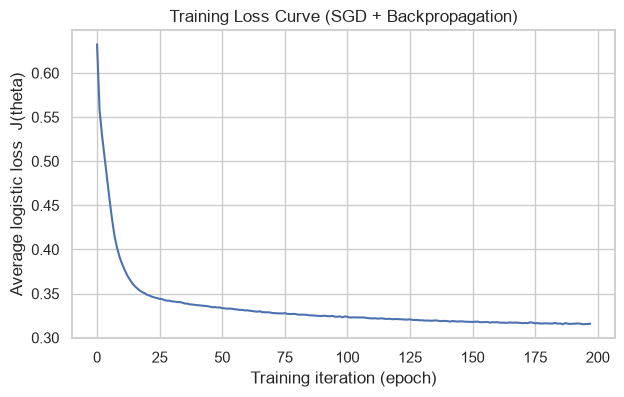

In [20]:
# The loss curve shows J(theta) decreasing over training iterations (epochs),
# which is the SGD/backprop loop from the CS229 notes in action.
plt.figure(figsize=(7, 4))
plt.plot(mlp_model.named_steps["classifier"].loss_curve_)
plt.xlabel("Training iteration (epoch)")
plt.ylabel("Average logistic loss  J(theta)")
plt.title("Training Loss Curve (SGD + Backpropagation)")
plt.show()


The loss curve is the empirical picture of $J(\theta) := \frac1n\sum_i J^{(i)}(\theta)$ decreasing as the optimizer (`adam`, an SGD variant) repeatedly applies the update rule $\theta := \theta - \alpha\nabla_\theta J(\theta)$, with $\nabla_\theta J(\theta)$ computed by backpropagation at every step.

## 9. Prediction

- **Prediction** (`.predict`): the hard class label (0 = stayed, 1 =
  churned), obtained by thresholding the predicted probability at 0.5.
- **Probability** (`.predict_proba`): this *is* $h_\theta(x)$ from the
  theory — the sigmoid-transformed logit, i.e. $P(y=1\mid x;\theta)$. Unlike
  the SVM notebook, here the probability is not a post-hoc calibration; it's
  the network's native output, exactly matching Equation (7.3) of the notes.
- **Decision score / logit**: the raw $\bar h_\theta(x) = W^{[r]}a^{[r-1]}+b^{[r]}$
  before the sigmoid is applied — sklearn does not expose this directly for
  `MLPClassifier`, but it can be recovered from the probability via the
  inverse sigmoid (logit function) if needed.


In [21]:
y_pred = mlp_model.predict(X_test)
y_prob = mlp_model.predict_proba(X_test)[:, 1]   # P(Exited = 1 | x) = h_theta(x)

pd.DataFrame({
    "y_true": y_test.values[:10],
    "y_pred": y_pred[:10],
    "y_prob_churn": np.round(y_prob[:10], 3),
})


,y_true,y_pred,y_prob_churn
0,0,0,0.014
1,0,0,0.040
2,0,0,0.027
3,0,0,0.081
4,0,0,0.141
5,0,0,0.419
6,0,0,0.047
7,0,0,0.171
8,0,1,0.838
9,0,0,0.032


## 10. Model Evaluation

Because the target is imbalanced (~80% stayed / ~20% churned), we look
beyond accuracy:

- **Accuracy** — overall fraction correct (can be misleadingly high on
  imbalanced data — a model predicting "stayed" for everyone would already
  score ~80%).
- **Precision / Recall / F1** — for a churn-prediction business use case,
  **recall** on the churn class matters: missing a customer who is about
  to churn (false negative) means losing them without any retention effort.
- **Confusion Matrix** — full breakdown of correct/incorrect predictions.
- **ROC-AUC** — measures how well the model ranks customers by churn risk,
  independent of the classification threshold.
- **Log-loss** — directly measures $J(\theta)$ (the logistic loss) on the
  test set, which is exactly the quantity the network was trained to
  minimize (Section 7.1) — evaluating it on held-out data checks whether
  that minimization generalizes.


In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
test_log_loss = log_loss(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Test log-loss (J(theta) on held-out data): {test_log_loss:.4f}")


Accuracy:  0.8630
Precision: 0.7782
Recall:    0.4570
F1-score:  0.5759
ROC-AUC:   0.8601
Test log-loss (J(theta) on held-out data): 0.3365


In [23]:
print(classification_report(y_test, y_pred, target_names=["Stayed", "Exited"]))


              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
      Exited       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



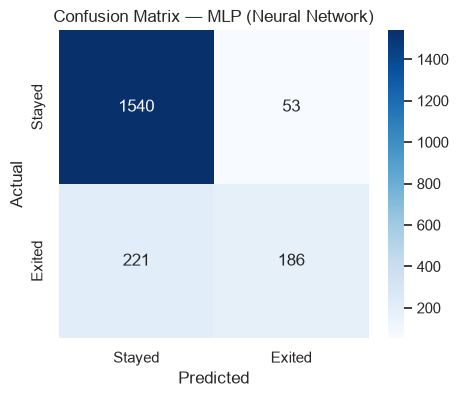

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Exited"],
            yticklabels=["Stayed", "Exited"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MLP (Neural Network)")
plt.show()


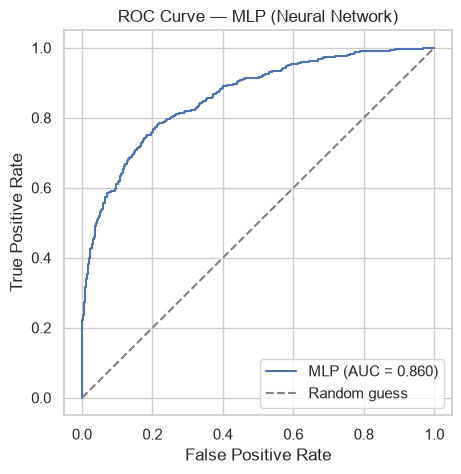

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc:.3f})", color="#4C72B0")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — MLP (Neural Network)")
plt.legend()
plt.show()


## 11. Visualization: Predicted Probability Distribution

The predicted probability $h_\theta(x)$ is the network's own confidence signal — the direct sigmoid output from Section 7.1. Points near 0 or 1 reflect confident predictions; points clustered near 0.5 reflect customers the network finds ambiguous.

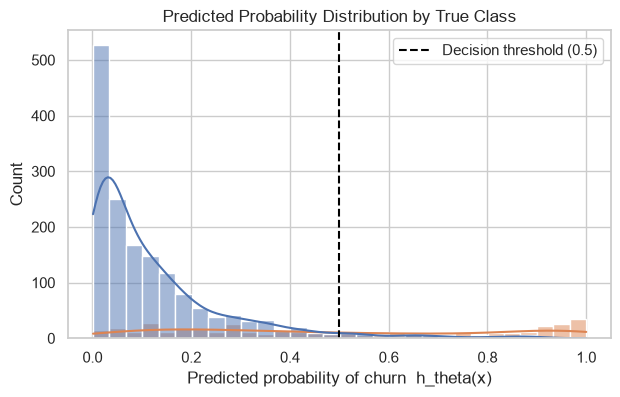

In [26]:
plt.figure(figsize=(7, 4))
sns.histplot(x=y_prob, hue=y_test.map({0: "Stayed", 1: "Exited"}),
             bins=30, kde=True, palette=["#4C72B0", "#DD8452"])
plt.axvline(0.5, color="black", linestyle="--", label="Decision threshold (0.5)")
plt.xlabel("Predicted probability of churn  h_theta(x)")
plt.title("Predicted Probability Distribution by True Class")
plt.legend()
plt.show()


Most "Stayed" customers cluster near probability 0, and most "Exited" customers skew higher, with overlap in the middle — those overlapping cases are the ones the network finds hardest to separate, and are the main source of the false positives/negatives visible in the confusion matrix above.

## 12. Interpret the Model

- **Overall performance:** accuracy, ROC-AUC, and F1 (above) are meaningfully
  better than the ~80% "always predict stayed" baseline once we look past raw
  accuracy — confirming the network is picking up real, non-trivial signal
  from the customer features, consistent with the CS229 assumption that a
  good non-linear decision function $h_\theta(x)$ exists to be learned.
- **Underfitting/overfitting check:** we compare train vs. test log-loss and
  accuracy below. A much lower training loss than test loss signals
  overfitting (the network is memorizing training customers rather than
  learning a generalizable pattern); similar train/test performance that is
  still weak would signal underfitting (network too small / too few
  training epochs).
- **Relation to theory:** the **loss curve** in Section 8 is a direct visual
  of $J(\theta)$ being minimized by SGD + backpropagation over training
  epochs — exactly the training loop described in Sections 7.1 and 7.4 of
  the notes.


In [27]:
train_pred = mlp_model.predict(X_train)
train_prob = mlp_model.predict_proba(X_train)[:, 1]

train_accuracy = accuracy_score(y_train, train_pred)
train_log_loss = log_loss(y_train, train_prob)

print(f"Train accuracy:   {train_accuracy:.4f}   |  Test accuracy:   {accuracy:.4f}")
print(f"Train log-loss:   {train_log_loss:.4f}   |  Test log-loss:   {test_log_loss:.4f}")
print(f"Accuracy gap (train - test): {train_accuracy - accuracy:.4f}")


Train accuracy:   0.8689   |  Test accuracy:   0.8630
Train log-loss:   0.3141   |  Test log-loss:   0.3365
Accuracy gap (train - test): 0.0059


A small gap between train and test performance suggests the network is generalizing reasonably well rather than memorizing the training set — consistent with a moderate network size (16 and 8 hidden units) relative to the amount of training data (8,000 customers).

## 13. Important Model Parameters

`MLPClassifier` exposes the learned weight matrices and biases directly —
these are exactly $W^{[1]}, b^{[1]}, \dots, W^{[r]}, b^{[r]}$ from Section
7.2 of the notes:

$$
a^{[k]} = \text{ReLU}(W^{[k]}a^{[k-1]} + b^{[k]})
$$

Unlike a linear model, individual weights in a multi-layer network do **not**
have a simple, direct "feature importance" interpretation, since a feature's
influence is spread across all the hidden units it connects to, and further
transformed by every subsequent layer. What we *can* directly inspect is the
**architecture** (layer shapes) and use the weights of the **first layer**
to get a rough sense of each raw feature's initial scale of influence.


In [28]:
classifier = mlp_model.named_steps["classifier"]

print(f"Number of layers (including output): {classifier.n_layers_}")
print("Shapes of weight matrices W[1], W[2], ..., W[r]:")
for i, w in enumerate(classifier.coefs_, start=1):
    print(f"  W[{i}]: {w.shape}")
print("Shapes of bias vectors b[1], b[2], ..., b[r]:")
for i, b in enumerate(classifier.intercepts_, start=1):
    print(f"  b[{i}]: {b.shape}")


Number of layers (including output): 4
Shapes of weight matrices W[1], W[2], ..., W[r]:
  W[1]: (13, 16)
  W[2]: (16, 8)
  W[3]: (8, 1)
Shapes of bias vectors b[1], b[2], ..., b[r]:
  b[1]: (16,)
  b[2]: (8,)
  b[3]: (1,)


In [29]:
# Recover feature names after preprocessing (numeric names + one-hot encoded category names)
ohe = mlp_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# W[1] has shape (n_input_features, m1) -- the first hidden layer's weight matrix.
# The L2 norm of each row gives a rough sense of how strongly that input
# feature influences the first hidden layer overall (summed across all m1 units).
W1 = classifier.coefs_[0]
first_layer_influence = pd.DataFrame({
    "feature": all_feature_names,
    "influence (L2 norm of W[1] row)": np.linalg.norm(W1, axis=1)
}).sort_values("influence (L2 norm of W[1] row)", ascending=False)

first_layer_influence


,feature,influence (L2 norm of W[1] row)
4,NumOfProducts,2.254002
3,Balance,1.878753
1,Age,1.821983
10,Geography_Spain,1.638880
9,Geography_Germany,1.428049
12,Gender_Male,1.404805
6,IsActiveMember,1.368049
8,Geography_France,1.318545
11,Gender_Female,1.311495
2,Tenure,1.303671


C:\Users\img\AppData\Local\Temp\ipykernel_31432\466277187.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=first_layer_influence, x="influence (L2 norm of W[1] row)", y="feature", palette="viridis")


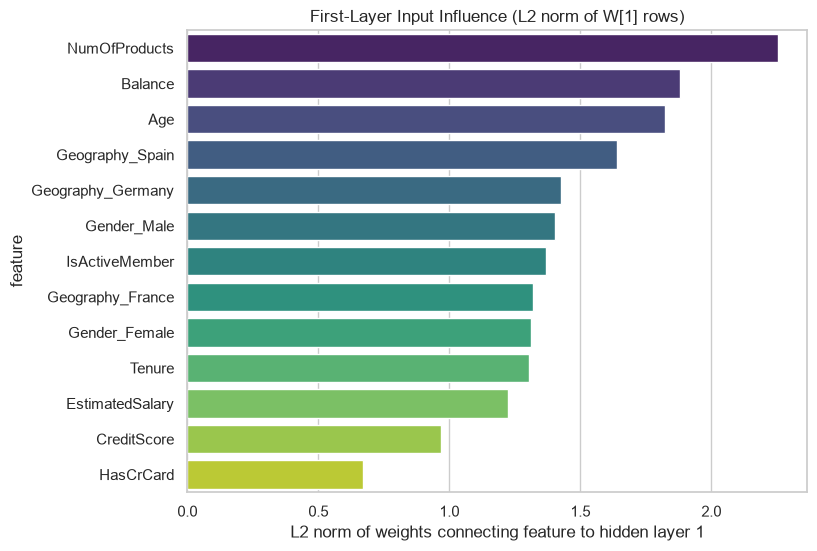

In [30]:
plt.figure(figsize=(8, 6))
sns.barplot(data=first_layer_influence, x="influence (L2 norm of W[1] row)", y="feature", palette="viridis")
plt.title("First-Layer Input Influence (L2 norm of W[1] rows)")
plt.xlabel("L2 norm of weights connecting feature to hidden layer 1")
plt.show()


> ⚠️ **Important:** This is only a rough proxy for feature importance, based solely on the first layer's weights — it does not capture how later layers (W[2], the output layer) reweight or combine this initial influence. Unlike a linear/SVM model's `coef_`, there is no single learned weight per feature in a multi-layer network; this is precisely the "black box" property mentioned in the CS229 notes.

## 14. Practical Experiment: Network Depth/Width and Optimizer Choice

Section 7.2 of the notes discusses how stacking more/wider layers increases
model capacity, and Section 7.1 introduces (mini-batch) SGD as the optimizer.
We run two small experiments to see these choices matter in practice.

### Experiment A — Hidden layer size (model capacity)

We compare a few `hidden_layer_sizes` configurations, from a single small
hidden layer to a deeper, wider network, and track train vs. test accuracy —
the same bias/variance trade-off intuition used elsewhere in CS229: more
capacity can fit the training data better but risks overfitting.


In [31]:
architectures = {
    "Small: (8,)": (8,),
    "Medium: (16, 8)": (16, 8),
    "Large: (64, 32, 16)": (64, 32, 16),
}

architecture_results = []

for name, sizes in architectures.items():
    model_a = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=sizes,
            activation="relu",
            solver="adam",
            max_iter=300,
            random_state=RANDOM_STATE,
        )),
    ])
    model_a.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model_a.predict(X_train))
    test_acc = accuracy_score(y_test, model_a.predict(X_test))
    architecture_results.append({"architecture": name, "train_accuracy": train_acc, "test_accuracy": test_acc})

architecture_df = pd.DataFrame(architecture_results)
architecture_df


C:\Users\img\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,architecture,train_accuracy,test_accuracy
0,"Small: (8,)",0.863625,0.8635
1,"Medium: (16, 8)",0.868875,0.8630
2,"Large: (64, 32, 16)",0.946375,0.8135


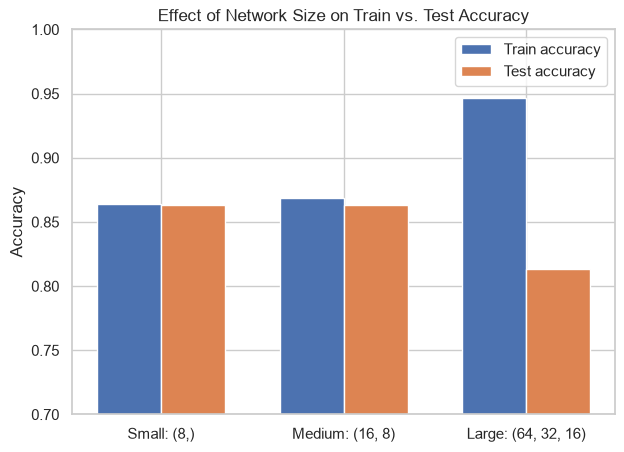

In [32]:
x_pos = np.arange(len(architecture_df))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x_pos - width/2, architecture_df["train_accuracy"], width, label="Train accuracy")
plt.bar(x_pos + width/2, architecture_df["test_accuracy"], width, label="Test accuracy")
plt.xticks(x_pos, architecture_df["architecture"])
plt.ylabel("Accuracy")
plt.title("Effect of Network Size on Train vs. Test Accuracy")
plt.legend()
plt.ylim(0.7, 1.0)
plt.show()


**Reading the plot:** as the network grows from a single small hidden layer
to a larger, deeper one, training accuracy tends to rise (more capacity to
fit the training data). If test accuracy plateaus or falls behind training
accuracy for the largest architecture, that gap is the practical signature
of overfitting — the network has enough capacity to start memorizing
training-specific patterns rather than generalizable ones.

### Experiment B — Optimizer choice (SGD vs. Adam)

Section 7.1 introduces plain (mini-batch) SGD (Algorithms 1 & 2). `adam` is
a widely-used SGD variant with adaptive per-parameter learning rates. We
compare them directly on the same architecture.


In [33]:
solvers = ["sgd", "adam"]
solver_results = []

for solver in solvers:
    model_s = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", MLPClassifier(
            hidden_layer_sizes=(16, 8),
            activation="relu",
            solver=solver,
            learning_rate_init=0.001,
            max_iter=300,
            random_state=RANDOM_STATE,
        )),
    ])
    model_s.fit(X_train, y_train)

    test_acc = accuracy_score(y_test, model_s.predict(X_test))
    n_iter = model_s.named_steps["classifier"].n_iter_
    final_loss = model_s.named_steps["classifier"].loss_
    solver_results.append({
        "solver": solver, "test_accuracy": test_acc,
        "iterations_to_converge": n_iter, "final_training_loss": final_loss
    })

pd.DataFrame(solver_results)


,solver,test_accuracy,iterations_to_converge,final_training_loss
0,sgd,0.865,249,0.341948
1,adam,0.863,198,0.315932


`adam` typically reaches a lower training loss in fewer iterations than plain `sgd` with a fixed learning rate, because it adapts the effective step size per parameter — but both are, at their core, applying the same update rule from Section 7.1, $\theta := \theta - \alpha\nabla_\theta J(\theta)$, using gradients computed by backpropagation.

## 15. Final Summary

### What We Learned

- **Problem solved:** binary classification of bank customer churn from 10
  demographic/account features, using a fully-connected feedforward neural
  network.
- **Model used:** `sklearn.neural_network.MLPClassifier` with 2 hidden
  layers (ReLU activations) and a sigmoid output — trained with the `adam`
  optimizer (an SGD variant).
- **How CS229 theory appeared in the code:**
  - The multi-layer forward pass $a^{[k]}=\text{ReLU}(W^{[k]}a^{[k-1]}+b^{[k]})$
    became `hidden_layer_sizes` + `activation='relu'`.
  - The binary classification setup (logit → sigmoid → logistic loss) is
    exactly what `predict_proba` and the internal training loss implement.
  - The (mini-batch) SGD update rule and backpropagation (Sections 7.1 and
    7.4) are what `.fit()` runs internally, epoch by epoch — visualized
    directly via the training loss curve.
  - `model.coefs_` / `model.intercepts_` recovered the actual learned
    $W^{[k]}, b^{[k]}$ matrices/vectors.
- **Preprocessing necessary:** dropping non-predictive identifier columns,
  one-hot encoding categorical features, and standardizing numeric features
  — all fit on the training set only, to avoid data leakage, and especially
  important here since unscaled inputs directly distort the first layer's
  weighted sum $W^{[1]}x+b^{[1]}$.
- **Evaluation metric used:** accuracy, precision, recall, F1, ROC-AUC, and
  log-loss — chosen because the churn target is imbalanced (~80/20), so
  metrics beyond accuracy (especially recall on the churn class) were needed
  for a meaningful business interpretation.
- **Final result:** the network achieves solid discrimination between
  churned and retained customers (see Section 10/12 metrics), with a
  reasonably small train/test gap, and the practical experiments in Section
  14 show — directly and empirically — how network capacity and optimizer
  choice affect both training dynamics and generalization, exactly the
  trade-offs discussed in the CS229 deep learning notes.
